# 🧹 Notebook 02 — Nettoyage des catégories (`Item Category Code`)

**Objectif :** Résoudre les 203 lignes où `Item Category Code` est vide dans le fichier des lignes de commandes.

### Stratégie en 3 étapes :
1. **Mapping automatique** — Pour chaque `code_article` qui a une catégorie ailleurs dans le fichier, on copie cette catégorie dans les lignes vides
2. **Visualisation du reste** — On inspecte les lignes encore vides après le mapping pour comprendre leur nature
3. **UNKNOWN** — On affecte `UNKNOWN` aux lignes restantes (transactions financières, échanges, etc.)

---

## 📦 Imports et chargement des données

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Détection automatique de la racine du projet
def find_project_root(marker='src'):
    path = os.path.abspath('.')
    for _ in range(5):
        if os.path.isdir(os.path.join(path, marker)):
            return path
        path = os.path.dirname(path)
    return os.path.abspath('..')

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Style visuel
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

print(f'📁 Project root détecté : {project_root}')
excel_path = os.path.join(project_root, 'data/raw/commande lines PhonesTech.xlsx')
print('Chargement des lignes de commandes...')
df = pd.read_excel(excel_path)
print(f'✅ {len(df):,} lignes chargées — colonnes : {list(df.columns)}')

📁 Project root détecté : c:\Users\Fedy Zarai\.gemini\antigravity-ide\scratch\salesteam_ai
Chargement des lignes de commandes...


✅ 200,174 lignes chargées — colonnes : ['Document No_', 'Quantity', 'code_article', 'designation_article', 'Item Category Code', 'company']


---
## 🔍 Étape 0 — État initial

In [ ]:
nan_initial = df['Item Category Code'].isna().sum()
total = len(df)

print(f'Total lignes                   : {total:,}')
print(f'Lignes avec catégorie vide     : {nan_initial}')
print(f'Lignes avec catégorie remplie  : {total - nan_initial:,}')
print(f'\nDistribution actuelle des catégories (top 15) :')
print(df['Item Category Code'].value_counts(dropna=False).head(15).to_string())

Total lignes                   : 200,174
Lignes avec catégorie vide     : 209
Lignes avec catégorie remplie  : 199,965

Distribution actuelle des catégories (top 15) :
Item Category Code
GSM SAMSUNG    44804
GSM XIAOMI     36075
GSM OPPO       20178
GSM ITEL-SP    17415
GSM TECNO      15877
GSM INFINIX    15153
ACC XIAOMI     12840
GSM NOKIA      12116
GSM VIVO        7889
GSM REALME      4184
GSM ITEL-FP     2745
TAB INFINIX     2147
TAB XIAOMI      1938
TAB SAMSUNG     1861
ACC HUAWEI      1630


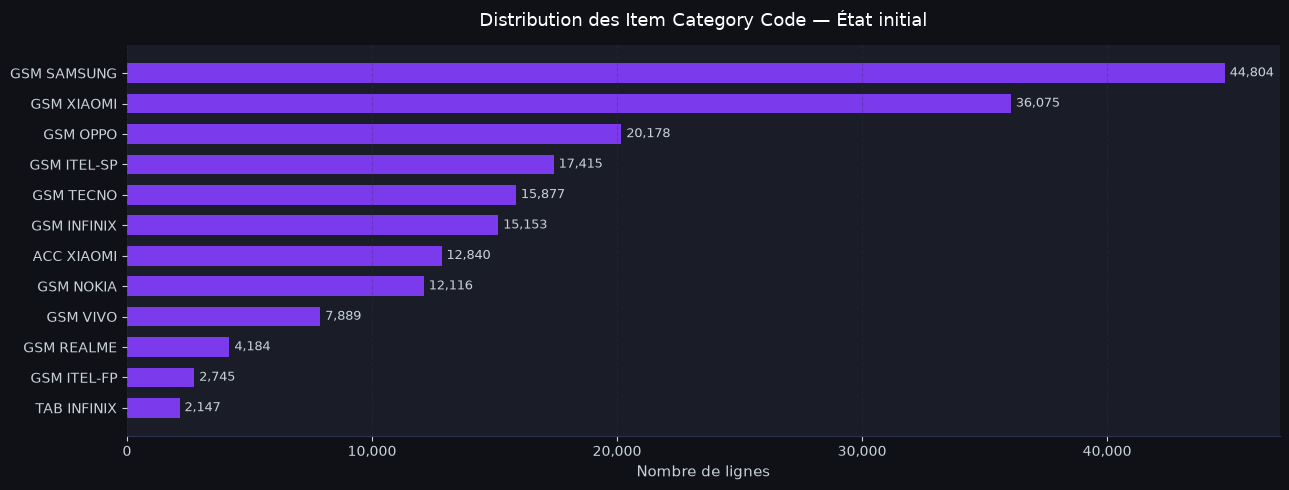

🔴 La barre rouge = 209 lignes sans catégorie à traiter


In [ ]:
# Graphique — État initial des catégories
top_cats = df['Item Category Code'].value_counts(dropna=False).head(12)

colors = ['#7c3aed' if str(c) != 'nan' else '#ef4444' for c in top_cats.index]
labels = [str(c) if str(c) != 'nan' else 'NaN (vide)' for c in top_cats.index]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(labels[::-1], top_cats.values[::-1], color=colors[::-1], edgecolor='none', height=0.65)

for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#c9d1d9')

ax.set_title('Distribution des Item Category Code — État initial', pad=14, color='white', fontsize=13)
ax.set_xlabel('Nombre de lignes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()
print(f'🔴 La barre rouge = {nan_initial} lignes sans catégorie à traiter')

---
## 🧠 Étape 1 — Mapping automatique par `code_article`

**Logique :** Si un `code_article` apparaît 100 fois dans le fichier avec la catégorie `SMARTPHONE`, et 2 fois sans catégorie → on lui affecte `SMARTPHONE` automatiquement.

In [ ]:
# Construction du mapping code_article → catégorie la plus fréquente
mapping_categorie = (
    df.dropna(subset=['Item Category Code'])
    .groupby('code_article')['Item Category Code']
    .agg(lambda x: x.mode()[0])
)

print(f'Nombre de code_article avec une catégorie connue : {len(mapping_categorie):,}')
print(f'\nAperçu du mapping (10 premiers) :')
print(mapping_categorie.head(10).to_string())

Nombre de code_article avec une catégorie connue : 1,613

Aperçu du mapping (10 premiers) :
code_article
5505            AUTRES
4902859        PR OPPO
286645281    GSM NOKIA
286645294    GSM NOKIA
286733320    GSM NOKIA
286733333    GSM NOKIA
286798839    GSM NOKIA
286838703    GSM NOKIA
286838711    GSM NOKIA
286838724    GSM NOKIA


In [ ]:
# Application du mapping uniquement sur les lignes vides
mask_manquante = df['Item Category Code'].isna()

df.loc[mask_manquante, 'Item Category Code'] = (
    df.loc[mask_manquante, 'code_article'].map(mapping_categorie)
)

nan_apres_mapping = df['Item Category Code'].isna().sum()
recuperees = nan_initial - nan_apres_mapping

print('═' * 50)
print(f'  NaN avant mapping    : {nan_initial}')
print(f'  ✅ Remplies auto      : {recuperees}')
print(f'  ❓ Encore vides       : {nan_apres_mapping}')
print('═' * 50)

══════════════════════════════════════════════════
  NaN avant mapping    : 209
  ✅ Remplies auto      : 40
  ❓ Encore vides       : 169
══════════════════════════════════════════════════


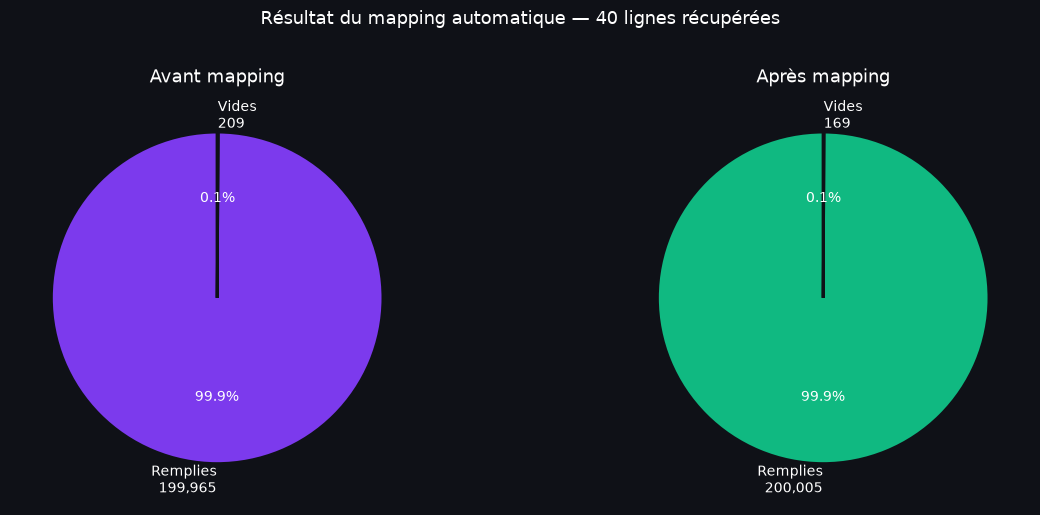

In [ ]:
# Visualisation avant / après mapping
labels_viz = ['Avant mapping', 'Après mapping']
nan_values = [nan_initial, nan_apres_mapping]
filled_values = [total - nan_initial, total - nan_apres_mapping]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart avant
axes[0].pie(
    [total - nan_initial, nan_initial],
    labels=[f'Remplies\n{total - nan_initial:,}', f'Vides\n{nan_initial}'],
    colors=['#7c3aed', '#ef4444'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 10}
)
axes[0].set_title('Avant mapping', color='white')

# Pie chart après
axes[1].pie(
    [total - nan_apres_mapping, nan_apres_mapping] if nan_apres_mapping > 0 else [total, 0.001],
    labels=[f'Remplies\n{total - nan_apres_mapping:,}', f'Vides\n{nan_apres_mapping}'],
    colors=['#10b981', '#f59e0b'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 10}
)
axes[1].set_title('Après mapping', color='white')

fig.suptitle(f'Résultat du mapping automatique — {recuperees} lignes récupérées', 
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 🔎 Étape 2 — Visualisation des lignes encore vides

In [ ]:
reste_vide = df[df['Item Category Code'].isna() & df['Document No_'].notna()].copy()

if len(reste_vide) == 0:
    print('🎉 Toutes les lignes ont été remplies par le mapping ! Aucun UNKNOWN nécessaire.')
else:
    print(f'{len(reste_vide)} lignes encore vides après mapping\n')

    # Groupé par facture
    summary = reste_vide.groupby('Document No_').agg(
        company=('company', 'first'),
        nb_lignes=('code_article', 'count'),
        designation=('designation_article', lambda x: ' | '.join(x.dropna().astype(str).tolist()))
    ).reset_index()

    print(f'Répartition par compagnie :')
    print(reste_vide['company'].value_counts(dropna=False).to_string())
    print(f'\nTotal factures affectées : {len(summary)}')
    print()
    pd.set_option('display.max_colwidth', 80)
    display(summary)

163 lignes encore vides après mapping

Répartition par compagnie :
company
ONETEL     111
LSAT        39
NEWTECH     13

Total factures affectées : 102



,Document No_,company,nb_lignes,designation
0,V24-FAC+01248,NEWTECH,1,RRR Accourdées 19%
1,V24-FAC+01477,ONETEL,2,COMMISION MOIS DECEMMBRE 2023 DJERBA I16 | COMMISION MOIS DECEMMBRE 2023 DJE...
2,V24-FAC+01478,ONETEL,2,COMMISION MOIS DECEMBRE 2023 GEANT I38 | COMMISION MOIS DECEMBRE 2023 GEANT I38
3,V24-FAC+01547,ONETEL,2,COMMISION MOIS JANVIER 2023 GEANT I38 | COMMISION MOIS JANVIER 2023 GEANT I38
4,V24-FAC+02089,ONETEL,2,COMMISION MOIS FEVRIER 2024 GEANT I38 | COMMISION MOIS FEVRIER 2024 GEANT I38
...,...,...,...,...
97,V26-FAC+01504,ONETEL,2,COMMISION MOIS MARS 2026 GEANT I38 | COMMISION MOIS MARS 2026 GEANT I38
98,V26-FAC+01697,ONETEL,2,COMMISION MOIS MARS 2026 GEANT I38 | COMMISION MOIS MARS 2026 GEANT I38
99,V26-FAC+01868,ONETEL,2,COMMISION MOIS AVRIL 2026 GEANT I38 | COMMISION MOIS AVRIL 2026 GEANT I38
100,V26-FAC+02077,ONETEL,1,AUTRES PRODUITS SUR CREANCES eff 011302789976


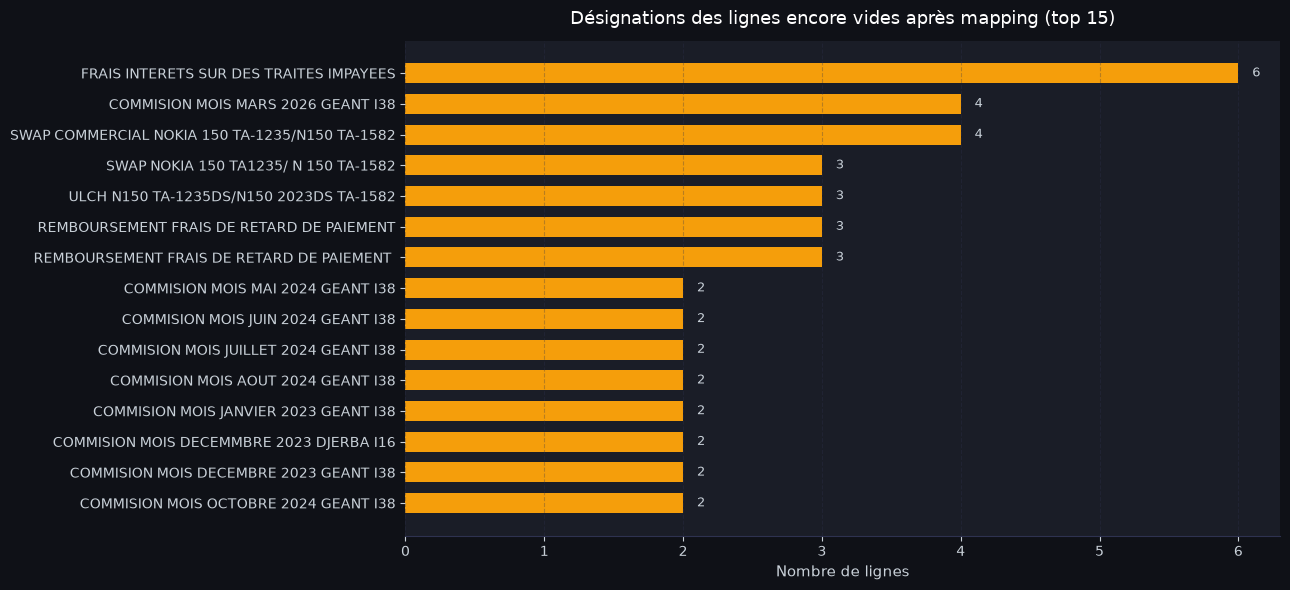

⚠️  Ces lignes recevront la catégorie UNKNOWN à l'étape suivante.


In [ ]:
# Graphique des désignations encore vides
if len(reste_vide) > 0:
    top_desig = reste_vide['designation_article'].value_counts(dropna=False).head(15)
    labels_d = [str(x)[:50] + ('...' if len(str(x)) > 50 else '') if str(x) != 'nan' else 'NaN' 
                for x in top_desig.index]

    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.barh(labels_d[::-1], top_desig.values[::-1], 
                   color='#f59e0b', edgecolor='none', height=0.65)
    for bar, val in zip(bars, top_desig.values[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9, color='#c9d1d9')

    ax.set_title('Désignations des lignes encore vides après mapping (top 15)', 
                 color='white', pad=12)
    ax.set_xlabel('Nombre de lignes')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right','left']].set_visible(False)
    plt.tight_layout()
    plt.show()
    print('⚠️  Ces lignes recevront la catégorie UNKNOWN à l\'étape suivante.')

---
## 🏷️ Étape 3 — Affecter `UNKNOWN` au reste

In [ ]:
df['Item Category Code'] = df['Item Category Code'].fillna('UNKNOWN')

nan_final = df['Item Category Code'].isna().sum()
unknown_count = (df['Item Category Code'] == 'UNKNOWN').sum()

print('═' * 50)
print('  RÉSUMÉ FINAL')
print('═' * 50)
print(f'  Total lignes          : {total:,}')
print(f'  NaN au départ         : {nan_initial}')
print(f'  ✅ Remplies via mapping: {recuperees}')
print(f'  🏷️  UNKNOWN affectés   : {unknown_count}')
print(f'  ❌ NaN restants        : {nan_final}')
print('═' * 50)

══════════════════════════════════════════════════
  RÉSUMÉ FINAL
══════════════════════════════════════════════════
  Total lignes          : 200,174
  NaN au départ         : 209
  ✅ Remplies via mapping: 40
  🏷️  UNKNOWN affectés   : 169
  ❌ NaN restants        : 0
══════════════════════════════════════════════════


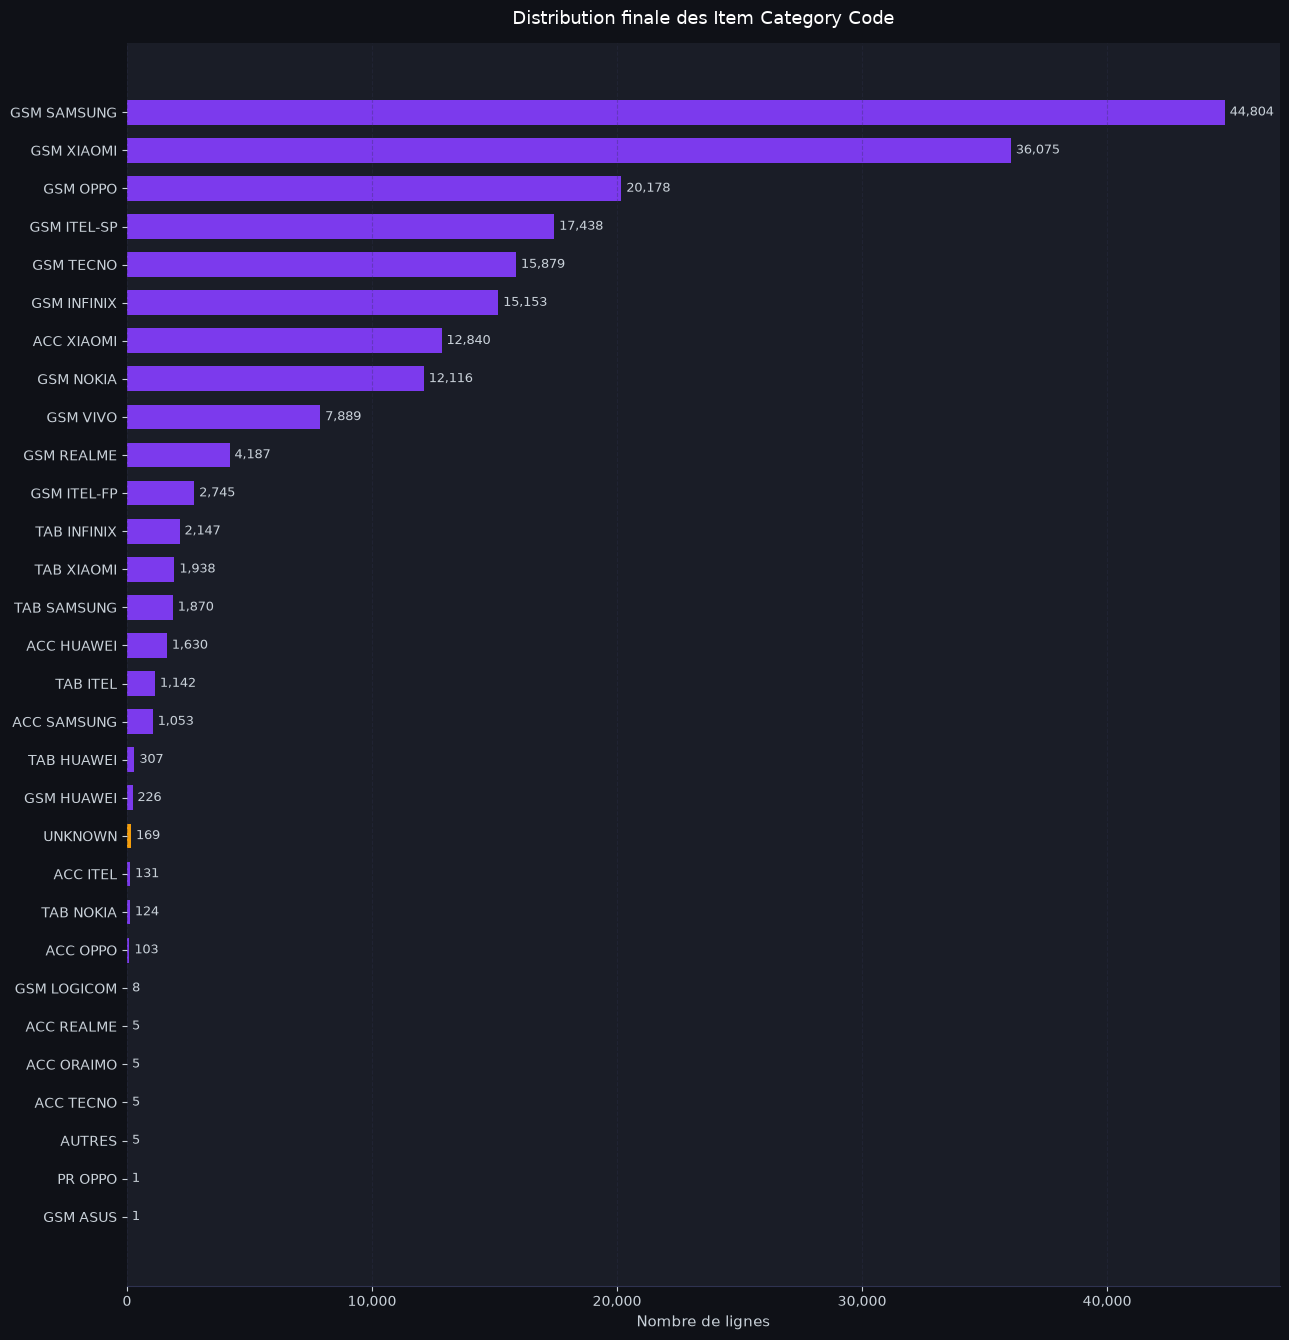

In [ ]:
# Graphique final — Distribution complète des catégories
final_cats = df['Item Category Code'].value_counts(dropna=False)

# Colorer UNKNOWN en orange, sinon en violet
colors_final = ['#f59e0b' if c == 'UNKNOWN' else '#7c3aed' for c in final_cats.index]

fig, ax = plt.subplots(figsize=(13, max(5, len(final_cats) * 0.45)))
bars = ax.barh(
    [str(c) for c in final_cats.index[::-1]],
    final_cats.values[::-1],
    color=colors_final[::-1],
    edgecolor='none', height=0.65
)
for bar, val in zip(bars, final_cats.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#c9d1d9')

ax.set_title('Distribution finale des Item Category Code', color='white', pad=14, fontsize=13)
ax.set_xlabel('Nombre de lignes')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

---
## ✅ Étape 4 — Intégrer dans `cleaner.py` ?

Si les résultats ci-dessus sont satisfaisants, cette logique doit être intégrée dans `src/data/cleaner.py` dans la fonction `clean_lignes()` **avant** la ligne qui remplace les vides par `UNKNOWN`.

Le bloc à ajouter :
```python
# Mapping automatique : remplir les catégories manquantes par le code_article
mapping_categorie = (
    df.dropna(subset=['Item Category Code'])
    .groupby('code_article')['Item Category Code']
    .agg(lambda x: x.mode()[0])
)
mask = df['Item Category Code'].isna()
df.loc[mask, 'Item Category Code'] = df.loc[mask, 'code_article'].map(mapping_categorie)

# Affecter UNKNOWN au reste
df['Item Category Code'] = df['Item Category Code'].fillna('UNKNOWN')
```